In [3]:
from sim.engine import SimConfig, run_monte_carlo
from sim.metrics import summarize
from sim.staking import stake_flat, stake_fraction, stake_kelly_fractional

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
cfg = SimConfig(
    p=0.55,
    d=1.91,
    bankroll0=1000.0,
    n_bets=1000,
    ruin_threshold=200.0,
)

In [5]:
strategies = {
    "flat_$10": lambda cfg: (lambda bankroll: stake_flat(bankroll, 10.0)),
    "fraction_1%": lambda cfg: (lambda bankroll: stake_fraction(bankroll, 0.01)),
    "fraction_2%": lambda cfg: (lambda bankroll: stake_fraction(bankroll, 0.02)),
    "kelly_0.25": lambda cfg: (
        lambda bankroll: stake_kelly_fractional(bankroll, cfg.p, cfg.d, 0.25)
    ),
    "kelly_0.50": lambda cfg: (
        lambda bankroll: stake_kelly_fractional(bankroll, cfg.p, cfg.d, 0.50)
    ),
}

In [6]:
summaries = []
dfs = {}

for name, factory in strategies.items():
    results = run_monte_carlo(cfg, factory, n_paths=20000, seed=42)
    summary, df = summarize(results)
    summary.insert(0, "strategy", name)
    summaries.append(summary)
    dfs[name] = df

final = pd.concat(summaries, ignore_index=True).sort_values("ruin_prob")
final

,strategy,ruin_prob,median_time_to_ruin,median_ending_bankroll,p05_ending_bankroll,median_max_drawdown
1,fraction_1%,0.00000,NaN,1583.619951,963.555342,0.195053
3,kelly_0.25,0.00000,NaN,1846.771476,926.819810,0.263126
0,flat_$10,0.00010,883.5,1505.000000,1008.400000,0.160457
2,fraction_2%,0.00015,824.0,2290.525058,847.525171,0.362659
4,kelly_0.50,0.00300,719.0,2864.233517,720.597663,0.473978


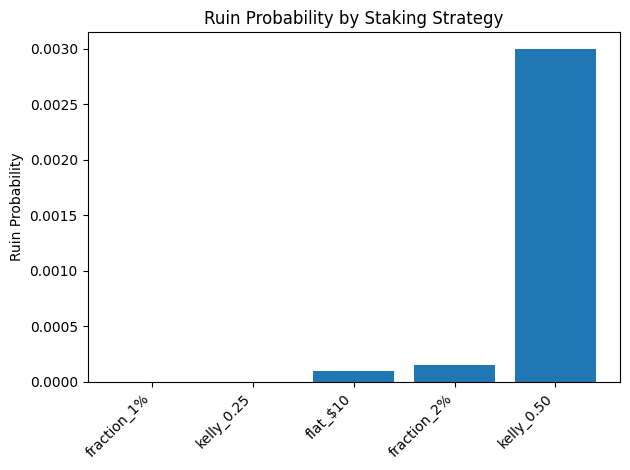

In [7]:
plt.figure()
plt.bar(final["strategy"], final["ruin_prob"])
plt.ylabel("Ruin Probability")
plt.xticks(rotation=45, ha="right")
plt.title("Ruin Probability by Staking Strategy")
plt.tight_layout()
plt.show()

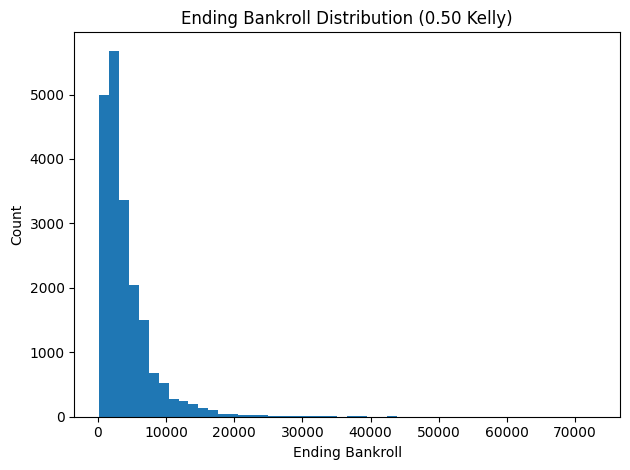

In [9]:
df = dfs["kelly_0.50"]

plt.figure()
plt.hist(df["ending_bankroll"], bins=50)
plt.title("Ending Bankroll Distribution (0.50 Kelly)")
plt.xlabel("Ending Bankroll")
plt.ylabel("Count")
plt.tight_layout()
plt.show()